# Process Mining Analysis of Trusteeship Agent

This notebook uses Process Mining through the pm4py tool to mine the flow of the trusteeship agent. It analyses the event log of that agent, discovers its process model, and uses conformance checks to compare that process model to the intended flow. 


## About the Agent

The trusteeship agent manages a long-running business process enabling a person to apply to be legal trustee for a beneficiary who is, for medical reasons, no longer able to make financial decisions. 

The agent uses an LLM to assess completeness of the application. The agent uses a ReAct pattern, deciding based on the request and  progress of the application what to do next. The user calls the agent either to launch a new application or add an update to an existing application. The agent has a set of **assess** tools that check completeness of the application form, medical, credit, criminal background, and personal references. The appplication keeps state in a DynamoDB table; the process may run for weeks or months. 

The following BPMN diagram describes the process that the agent uses: 
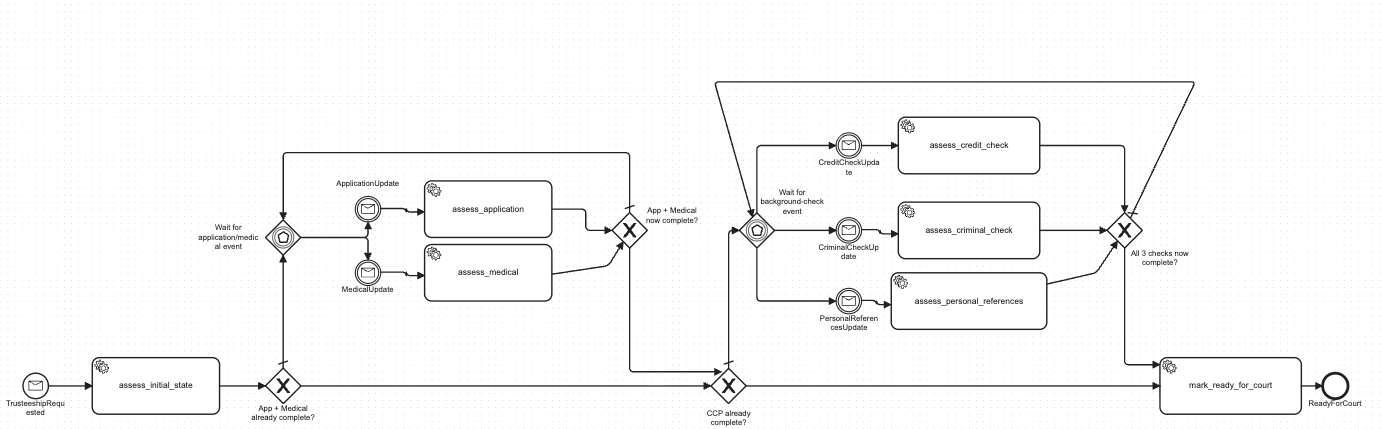

The process has four phases:
- Initial assessment.
- In parallel, assessment of completion of the application and the medical report that the beneficiary is incapacitated. These can happen in parallel. These are event-driven. Over time the applicant will submit updates to the agent on these asking for an updated assessment. This phase completes when both assessments are complete. It loops back as many times as needed until this condition is met.
- In parallel, assessment of completion of criminal check, credit check, and personal references check. This phases too is event-driven and loops back until complete.
- With everything prepared, mark the application ready for a court hearing.


## Event Log Summary
Load in the XES event log

The first finding is that assess_initial_state is not always the start activity. In some casees, assess_application is the start activity. Also, the intended model did not account for rejections. reject_activity is sometimes an end activity.

In [5]:
import pm4py
import pmagent_util
from pm4py.objects.bpmn.importer import importer as bpmn_importer
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments

log_xes = pm4py.read_xes('xeslogs/trusteeship_application_agent_DEFAULT_application.xes', return_legacy_log_object=True)
[ "start", pm4py.get_start_activities(log_xes), "end",  pm4py.get_end_activities(log_xes) ]

parsing log, completed traces ::   0%|          | 0/50 [00:00<?, ?it/s]

['start',
 {'assess_initial_state': 41, 'assess_application': 9},
 'end',
 {'mark_ready_for_court': 48, 'reject_application': 2}]

pm4py likes to use Pandas, so we convert the XES log to a dataframe.

In [4]:
df = pm4py.convert_to_dataframe(log_xes)
df

,concept:name,org:resource,time:timestamp,duration_s,trace_id,session_id,case:concept:name
0,assess_initial_state,joecool,2026-05-25 14:01:30.461000+00:00,0.001,87687b6159608d82,cbfd0af9-6c48-4644-b754-461266093ad4,b5865f12-ae96-433c-8293-8b89038f93a5
1,assess_application,joecool,2026-05-25 14:01:35.807000+00:00,0.001,7643a0b6239cc363,cbfd0af9-6c48-4644-b754-461266093ad4,b5865f12-ae96-433c-8293-8b89038f93a5
2,assess_medical,joecool,2026-05-25 14:01:42.297000+00:00,0.001,5870d1e4d8a6b14b,cbfd0af9-6c48-4644-b754-461266093ad4,b5865f12-ae96-433c-8293-8b89038f93a5
3,assess_medical,joecool,2026-05-25 14:01:47.273000+00:00,0.001,5b4b87cc5c97f879,cbfd0af9-6c48-4644-b754-461266093ad4,b5865f12-ae96-433c-8293-8b89038f93a5
4,assess_criminal_check,joecool,2026-05-25 14:01:52.808000+00:00,0.001,95768ec2a4673ff9,cbfd0af9-6c48-4644-b754-461266093ad4,b5865f12-ae96-433c-8293-8b89038f93a5
...,...,...,...,...,...,...,...
373,assess_medical,joecool,2026-05-25 13:29:05.018000+00:00,0.001,d31ab03265f03d05,5463aa13-5439-4587-86bc-ea8053cc55c0,3d810647-7b6b-4287-b7f3-0a0a47a1b028
374,assess_criminal_check,joecool,2026-05-25 13:29:11.013000+00:00,0.001,567738a56d4a4b9a,5463aa13-5439-4587-86bc-ea8053cc55c0,3d810647-7b6b-4287-b7f3-0a0a47a1b028
375,assess_credit_check,joecool,2026-05-25 13:29:16.151000+00:00,0.001,a64962ea711f8031,5463aa13-5439-4587-86bc-ea8053cc55c0,3d810647-7b6b-4287-b7f3-0a0a47a1b028
376,assess_personal_references,joecool,2026-05-25 13:29:35.099000+00:00,0.001,47c23379ff114078,5463aa13-5439-4587-86bc-ea8053cc55c0,3d810647-7b6b-4287-b7f3-0a0a47a1b028


Let's get a total case count and the most comment variants or activity paths through the flow.

In [6]:
variants=pm4py.get_variants(df, activity_key="concept:name", case_id_key="case:concept:name")
pmagent_util.dump_variants(df, variants)

Number of cases 50

Frequent variants
6 assess_initial_state->assess_application->assess_medical->assess_medical->assess_criminal_check->assess_credit_check->assess_personal_references->mark_ready_for_court
5 assess_initial_state->assess_application->assess_medical->assess_medical->assess_personal_references->assess_credit_check->assess_criminal_check->mark_ready_for_court

All variants
6 assess_initial_state->assess_application->assess_medical->assess_medical->assess_criminal_check->assess_credit_check->assess_personal_references->mark_ready_for_court
5 assess_initial_state->assess_application->assess_medical->assess_medical->assess_personal_references->assess_credit_check->assess_criminal_check->mark_ready_for_court
4 assess_initial_state->assess_application->assess_medical->assess_medical->assess_criminal_check->assess_personal_references->assess_credit_check->mark_ready_for_court
3 assess_initial_state->assess_application->assess_criminal_check->assess_medical->assess_medical->asse

There are MANY variants. Notice some have *stutter*. For examnple,in some variants assess_medical run twice in a row. That's allowed (the user submitted an initial report and then an update). But for the miner, let's simplify and treat as a single event. 

The output shows variants with stutter as well as stutter removed. Let's clean the dataframe to remove the stutter.


In [9]:
df = pmagent_util.deduplicate_agent_stutter(df)

# now check variants again, stutter gone?
variants=pm4py.get_variants(df, activity_key="concept:name", case_id_key="case:concept:name")
pmagent_util.dump_variants(df, variants)

--- Data Cleaning Metrics ---
Original Event Count: 322
Cleaned Event Count:  322
Dropped Stutter Rows: 0 (0.00%)
Number of cases 50

Frequent variants
6 assess_initial_state->assess_application->assess_medical->assess_personal_references->assess_credit_check->assess_criminal_check->mark_ready_for_court
6 assess_initial_state->assess_application->assess_medical->assess_criminal_check->assess_credit_check->assess_personal_references->mark_ready_for_court
5 assess_initial_state->assess_application->assess_medical->assess_criminal_check->assess_personal_references->assess_credit_check->mark_ready_for_court

All variants
6 assess_initial_state->assess_application->assess_medical->assess_personal_references->assess_credit_check->assess_criminal_check->mark_ready_for_court
6 assess_initial_state->assess_application->assess_medical->assess_criminal_check->assess_credit_check->assess_personal_references->mark_ready_for_court
5 assess_initial_state->assess_application->assess_medical->assess_cr

## Discovery

### Attempt Zero

From the event log, discover the process. For comparison, bring in our intended model so it can be compared. Recall, we drew our intended model (shown above) as a BPMN process using bpmn.io open-source editor.

To discover the process, we use the inductive miner. The Inductive Miner uses a top-down, divide-and-conquer approach that recursively breaks the event log down into standard workflow structures: sequences, loops, exclusive-or (XOR) choices, and parallel paths. By default, it guarantees a mathematically sound model that fits all the cases in the log. However, to achieve this perfect fitness, it tends to overgeneralize, meaning it can create a model that is highly structured but occasionally too permissive. Fortunately, the algorithm can be configured to filter out infrequent variants and tolerate noise.

We visualize these models using both standard BPMN and the more academically focused Petri Net. We include Petri Nets because they are the foundational language of process mining theory, allowing us to mathematically demonstrate concurrency, states, and token-based playback.

What we see is concerning. The discovered model looks about right, capturing the expected activities (tools) in conditional and parallel blocks (diamonds with x and +, respectively). But the intended model looks so different that it cannot be reasonably compared to the discovered model. 

We have an immediate action to fix the intended model. First, the event log will certainly not contain triggering events like ApplicationUpdates. Having them in the model will throw off the miner. For the same reason, let's also remove the event-based gateway (diamond with an E). Futhermore, the model doesn't convey the paralleism and looping in the two middle phases. 

Intended BPMN model


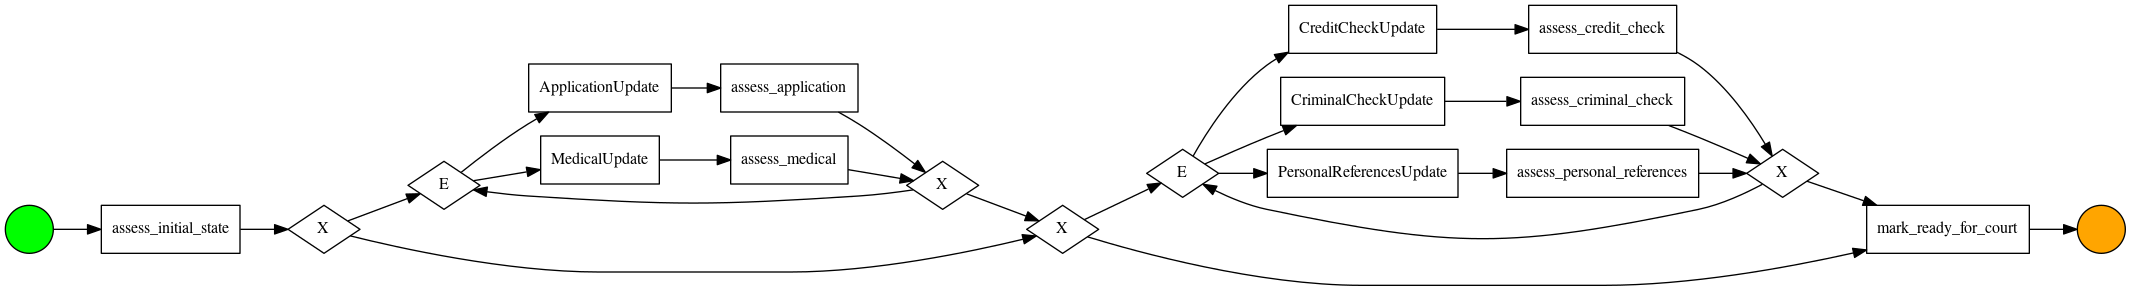

Discovered BPMN model


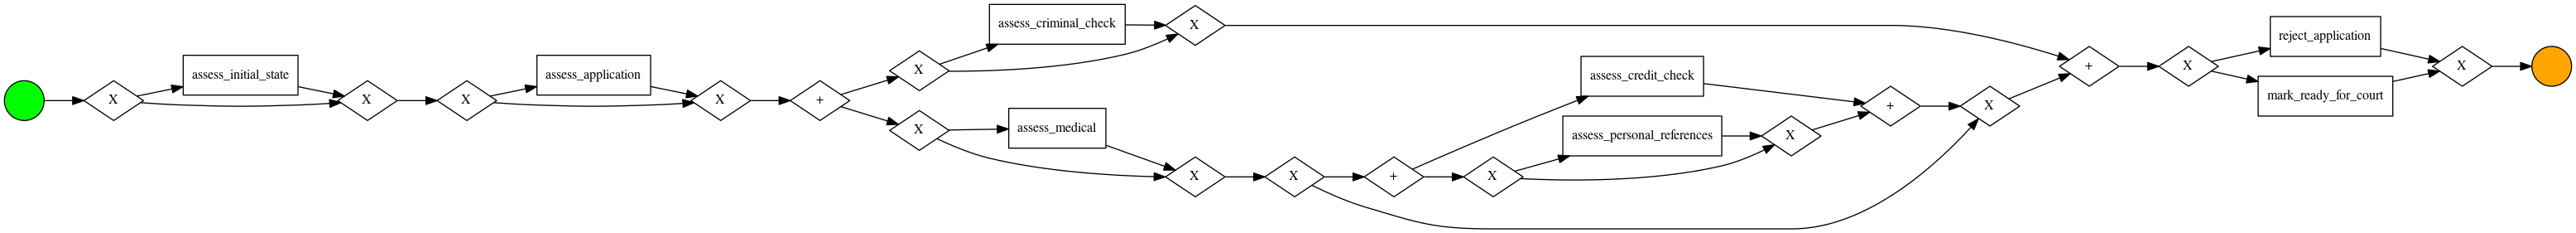

Intended Petri net


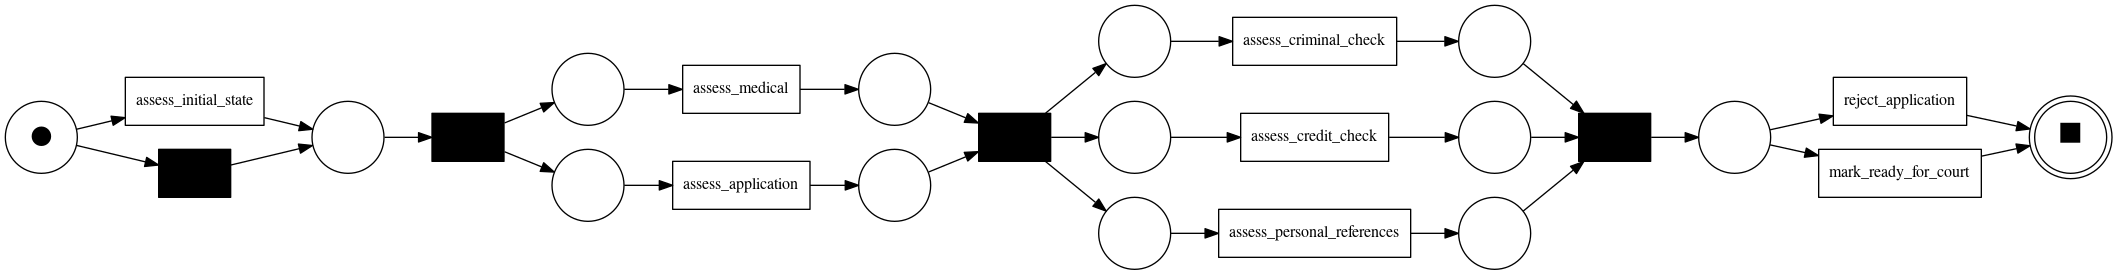

Discovered Petri net


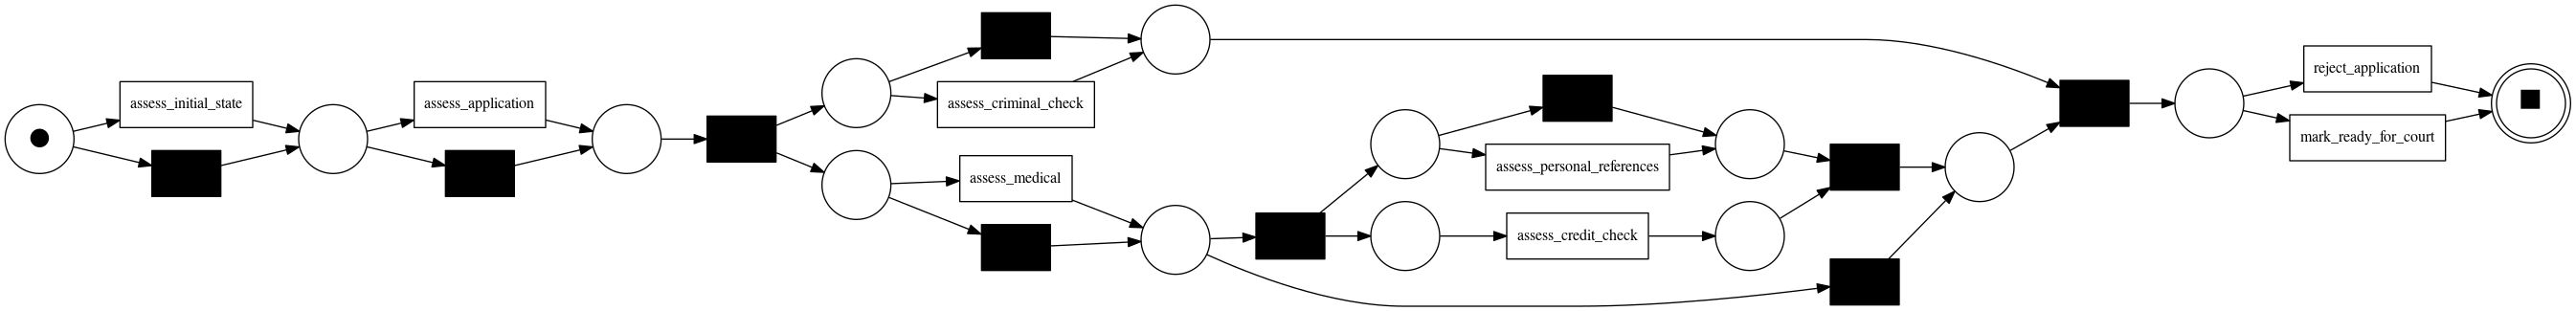

In [14]:
intended_bpmn_model0 = bpmn_importer.apply("../agents/trusteeship/intended_flow.bpmn")
intended_pn_net0, intended_pn_im0, intended_pn_fm0 = pm4py.convert_to_petri_net(intended_bpmn_model0)

discovered_bpmn_model = pm4py.discover_bpmn_inductive(df)
disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm  = pm4py.discover_petri_net_inductive(df)

print("Intended BPMN model")
pm4py.view_bpmn(intended_bpmn_model)
print("Discovered BPMN model")
pm4py.view_bpmn(discovered_bpmn_model)
print("Intended Petri net")
pm4py.view_petri_net(intended_pn_net, intended_pn_im, intended_pn_fm)
print("Discovered Petri net")
pm4py.view_petri_net(disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm)

### Redraw intended model

The intended model is not a bad model, but let's give the miner a model that can be tied better to the event log. We could redraw the BPMN model in an editor like bpmn.io, but let's be quick and tactical and sketch it out in the text language supported by pm4py! See if you can follow the notation in the next code cell that creates the final_narrative_string. It's fairly intuitive.

Draw the new intended model and compare it to the discovered model. We draw both in BPMN form and as Petri Nets (customary for PM analysis). They look much more similar now.

Generated BPMN from Text String:


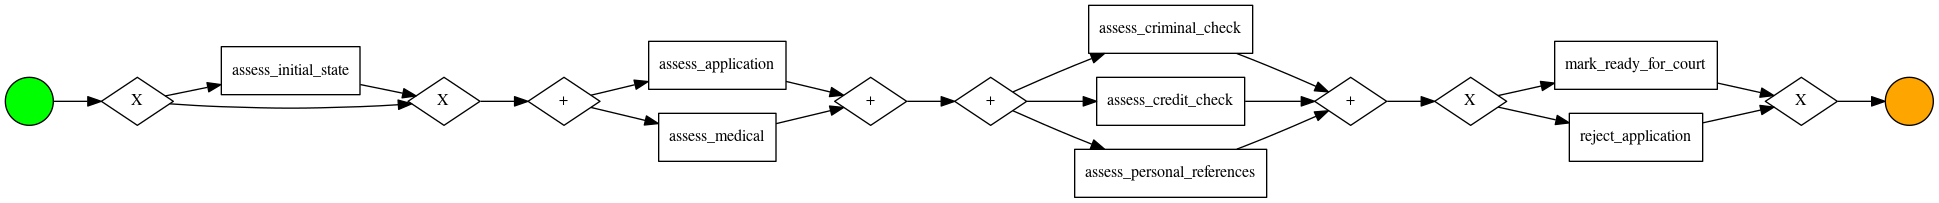

Discovered inductive BPMN


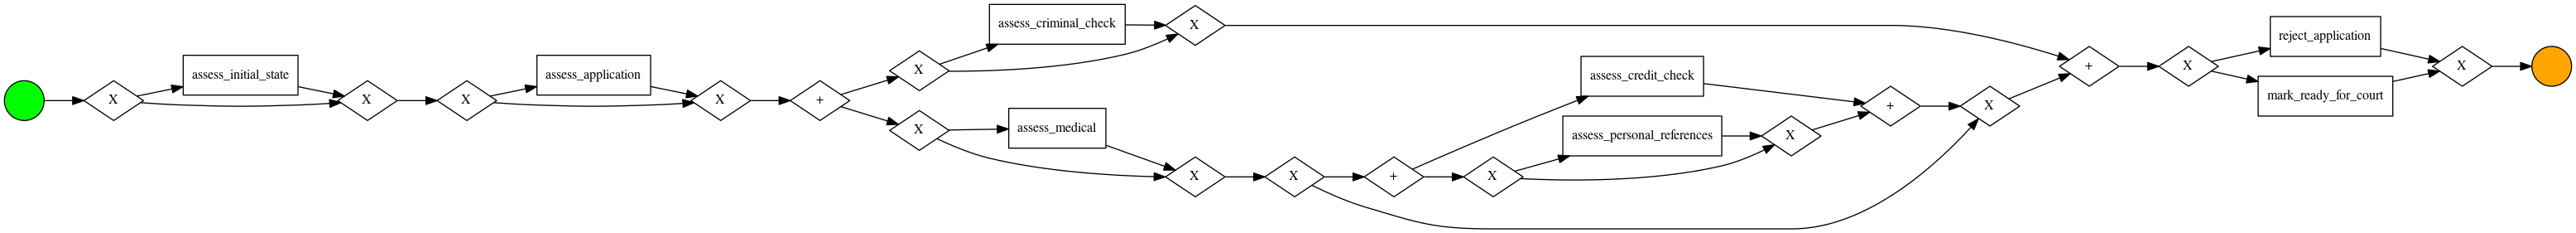

Generated Petri Net from Text String:


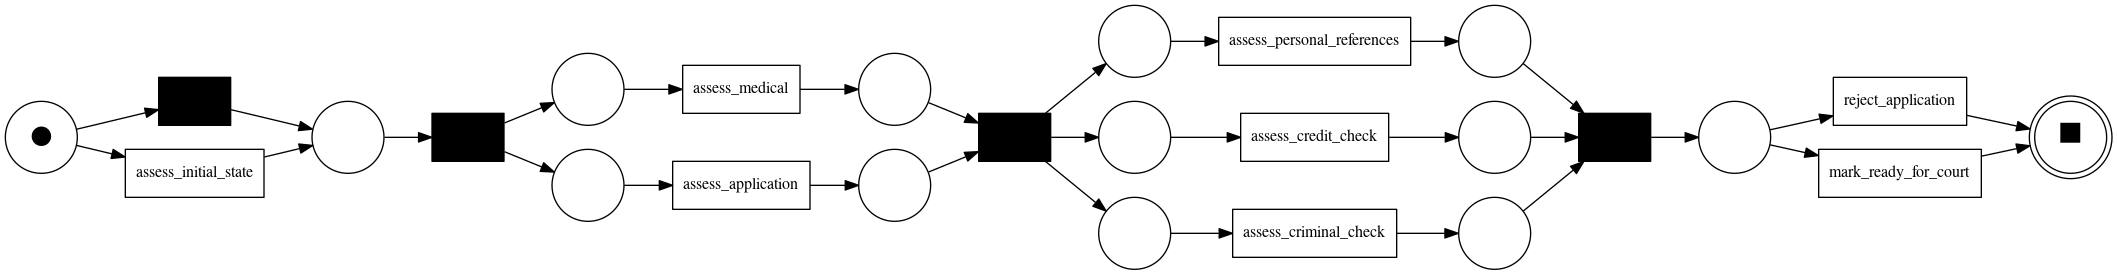

Discovered inductive Petri Net


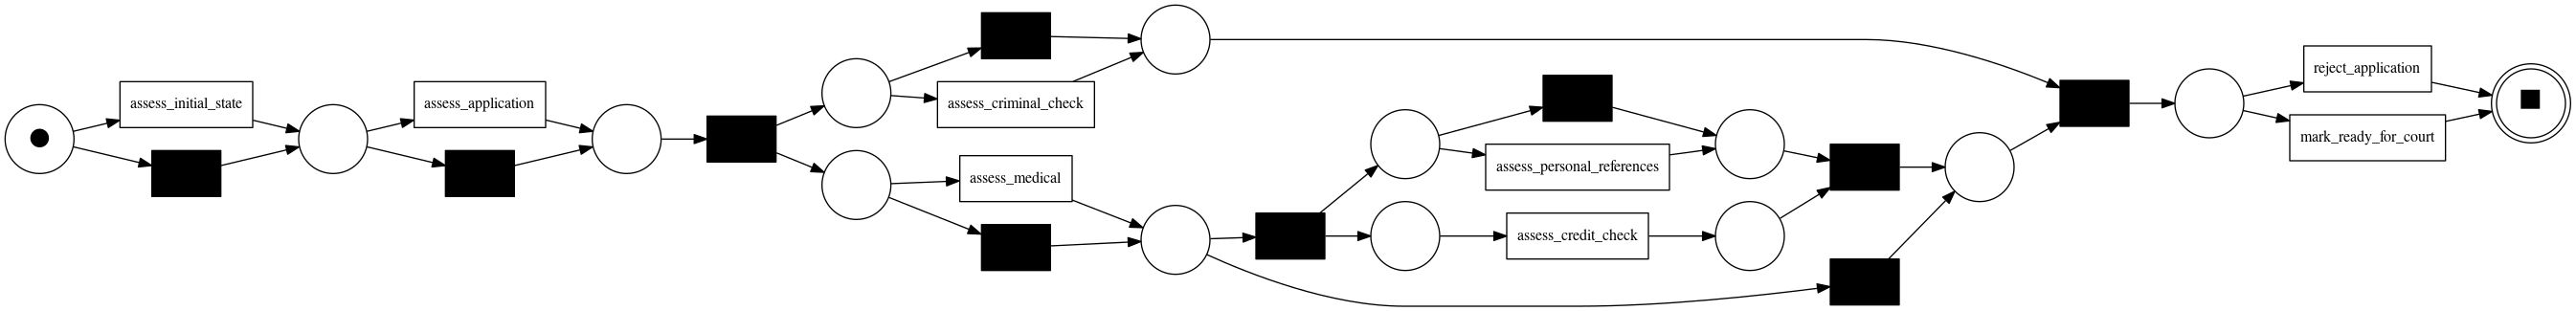

In [16]:
# Phase 1
intake_phase = "X( 'assess_initial_state', tau )"

# Phase 2
app_completeness = "+( 'assess_application', 'assess_medical' )"

# Phase 3
screenings = "+( 'assess_criminal_check', 'assess_credit_check', 'assess_personal_references' )"

# Phase 4 - and this time include rejects
outcome_phase = "X( 'mark_ready_for_court', 'reject_application' )"

# --- THE CORRECTED COMPILE ---
# We sequence the processing phases linearly: Intake -> Apps -> Screenings
core_processing = f"->( {intake_phase}, {app_completeness}, {screenings} )"

# Then we sequence the core processing highway straight into the outcome phase
final_narrative_string = f"->( {core_processing}, {outcome_phase} )"

intended_tree = pm4py.parse_process_tree(final_narrative_string)

# 3. Convert that Process Tree directly into a formal Petri Net and BPMN
intended_bpmn_model = pm4py.convert_to_bpmn(intended_tree)
intended_pn_net, intended_pn_im, intended_pn_fm = pm4py.convert_to_petri_net(intended_tree)

# 4. View it immediately to confirm the structure layout is correct
print("Generated BPMN from Text String:")
pm4py.view_bpmn(intended_bpmn_model)

print("Discovered inductive BPMN")
pm4py.view_bpmn(discovered_bpmn_model)

print("Generated Petri Net from Text String:")
pm4py.view_petri_net(intended_pn_net, intended_pn_im, intended_pn_fm)

print("Discovered inductive Petri Net")
pm4py.view_petri_net(disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm)


### Alternative Algorithms
We try out a few additional mining algorithms.

The first is to run inductive with "less noise".

We also run the Heuristic Miner. The Inductive Miner uses a top-down approach that forces raw event logs into strict, mathematically sound structural blocks, which guarantees no deadlocks but often sacrifices precision by overgeneralizing allowable paths. In contrast, the Heuristic Miner takes a pragmatic, statistical approach based on frequency thresholds and activity dependencies, making it vastly superior at filtering out real-world noise and preserving precise agent paths. However, because the Heuristic Miner maps local dependencies instead of rigid global blocks, it does not guarantee a mathematically sound model, presenting a direct trade-off between structural perfection and practical diagnostic clarity.

We draw the Petri Nets for both. The heuristic model looks much different! 

The stark visual difference between these two discovered nets comes down to a fundamental conflict in process mining philosophy.

The Top Net (Inductive) Enforces Structural Syntax: The Inductive Miner operates like a strict compiler. It refuses to map an arrow unless it can fit that transition into a formal, nested hierarchy (a Process Tree). When it encounters the parallel execution of the credit, reference, and criminal checks, it builds a clean, isolated multi-branch gateway. It uses pairs of black invisible transitions as strict structural brackets—one pair to cleanly split the tokens, and one pair to cleanly join them back together before moving to the next stage.

The Heuristic Miner (bottom) operates like a correlation matrix, ignoring global structure to map independent statistical dependencies between individual pairs of activities. Because it natively outputs an unconstrained, flat graph rather than rigid blocks, concurrent tasks that execute in arbitrary sequences result in a web of custom, direct pathways. The visual "spaghetti" is actually a side effect of translation: when forcing PM4Py to convert this open-ended graph into a formal Petri Net, the engine must mathematically ensure tokens don't get trapped. Lacking the clean block structures of the inductive method, the compiler is forced to invent a complex layout of dummy places (circles) and stacked invisible transitions (black boxes) to manually route tokens around those unconstrained local paths.

Neither of these is an improvement on the inductively discovered process from above.

Discovered Petri net - less noise


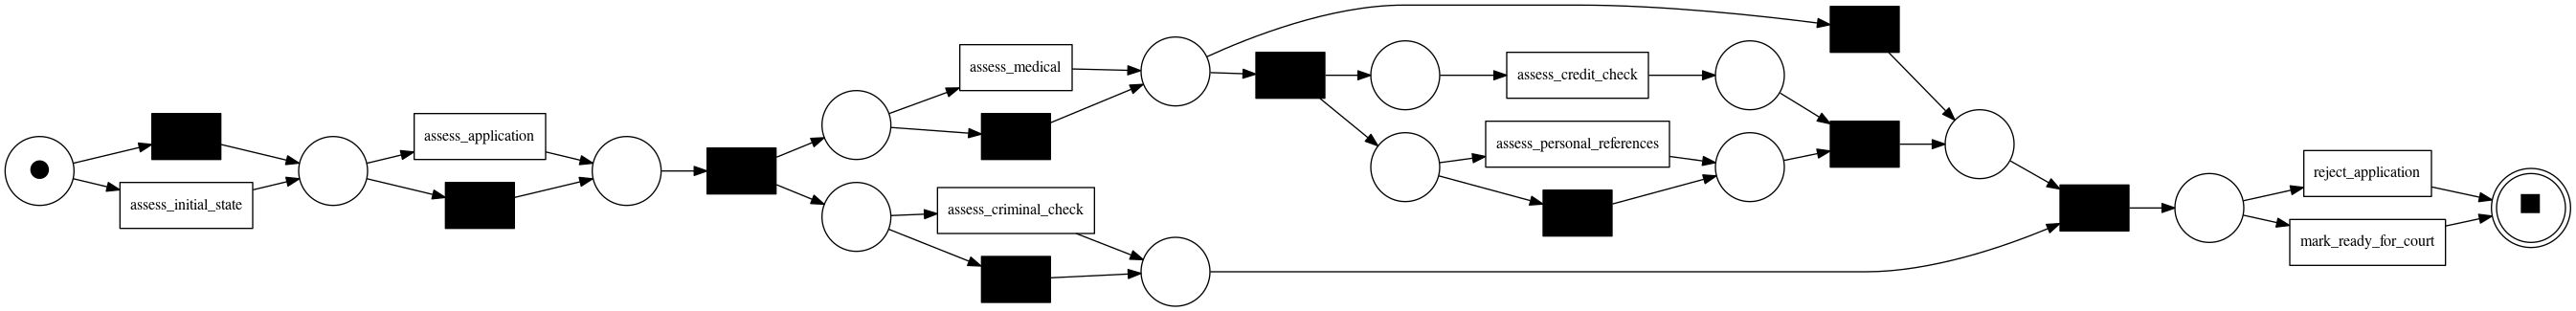

Discovered Petri net - heuristic


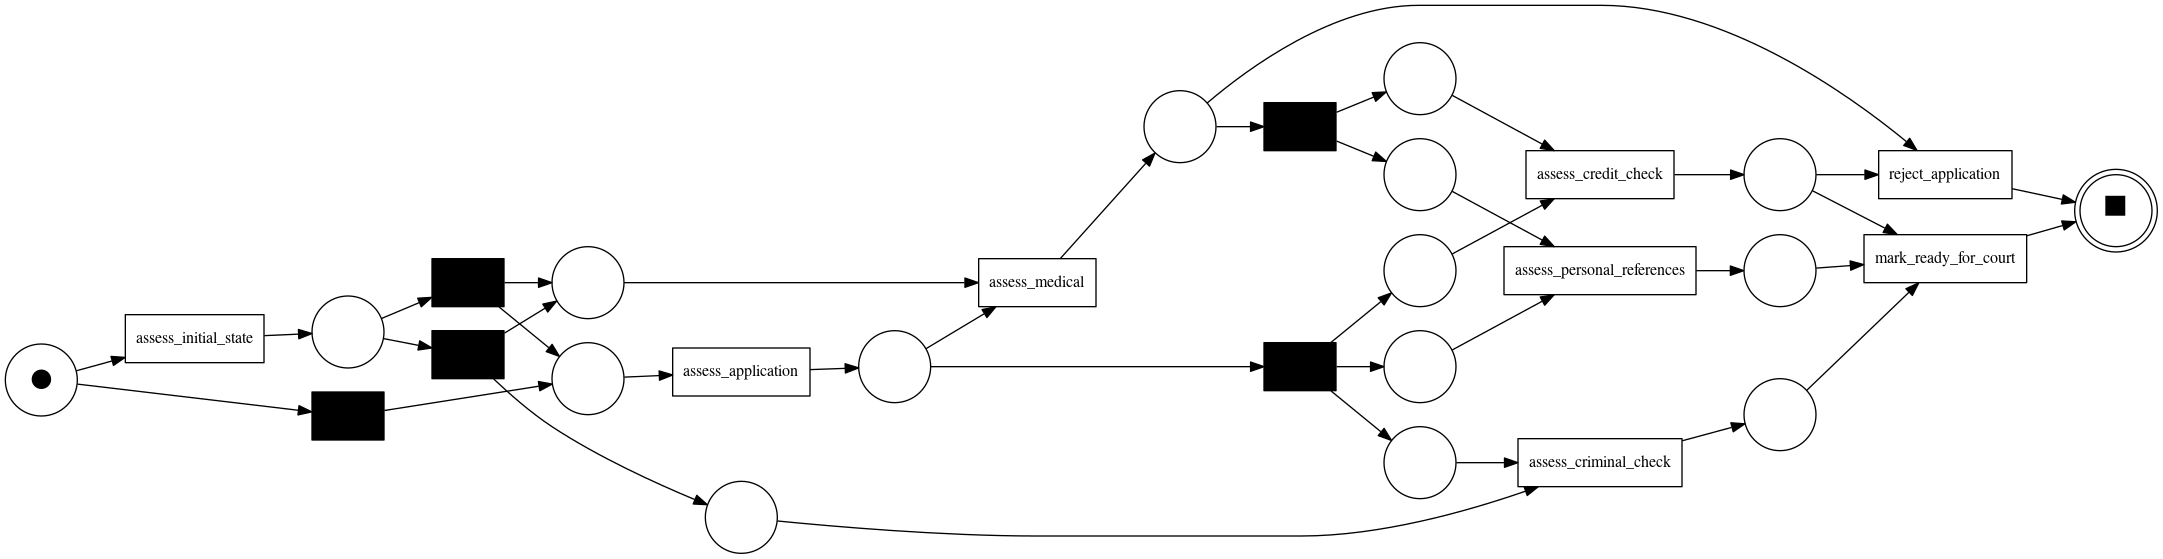

In [13]:
less_noise_param=0.8
disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm  = pm4py.discover_petri_net_inductive(df, less_noise_param)
disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm  = pm4py.discover_petri_net_heuristics(df)

print("Discovered Petri net - less noise")
pm4py.view_petri_net(disc_pn_ind_quiet_net, disc_pn_ind_quiet_im, disc_pn_ind_quiet_fm)
print("Discovered Petri net - heuristic")
pm4py.view_petri_net(disc_pn_heu_net, disc_pn_heu_im, disc_pn_heu_fm)

A Process Tree is a hierarchical, block-structured representation of a workflow that models execution logic as a mathematical tree rather than a free-form graph. It has no loops and will never look like spaghetti. For this agent, the inductive Petri Net was clear enough, so the process tree representation doesn't add much clarity.

Read it from left to right. As you move in that direction, you encounter several levels of tree. For each level, read top to bottom.

Level 1: At the far left, we see this tree starts as a sequence ("seq").

Level 2: Moving right to the next level, we see that the sequence is an XOR, another XOR, and AND, and another XOR.

Level 3: Moving right to the next level, we can see the following:
- The first XOR from Level 2 leads either to the end (small black dot) or assess_initial state.
- The second XOR from Level 2 leads either to the end or assess_application.
- The AND leads to an XOR or a SEQ.
- The third XOR from Level 2 leads to either reject_application or mark_ready_for court

And so on...

Let's traverse it from left to right/top-to-bottom to hit as many activities as possible. It reveals a problem. 
- assess_initial_state
- assess_application
- and ( assess_criminal_check, assess_medical, assess_credit_check, assess_personal_references)
- mark_ready_for_court XOR reject_application

The problem is that assess_medical really should be done in parallel with assess_application. And assess_criminal_check should be done with assess_credit_check and assess_personal_references.

The tree seems to allow an unwanted order for assess_medical and assess_criminal_check.

Note to self: find out why. We'll get to this below in the Conformance section.

Process tree


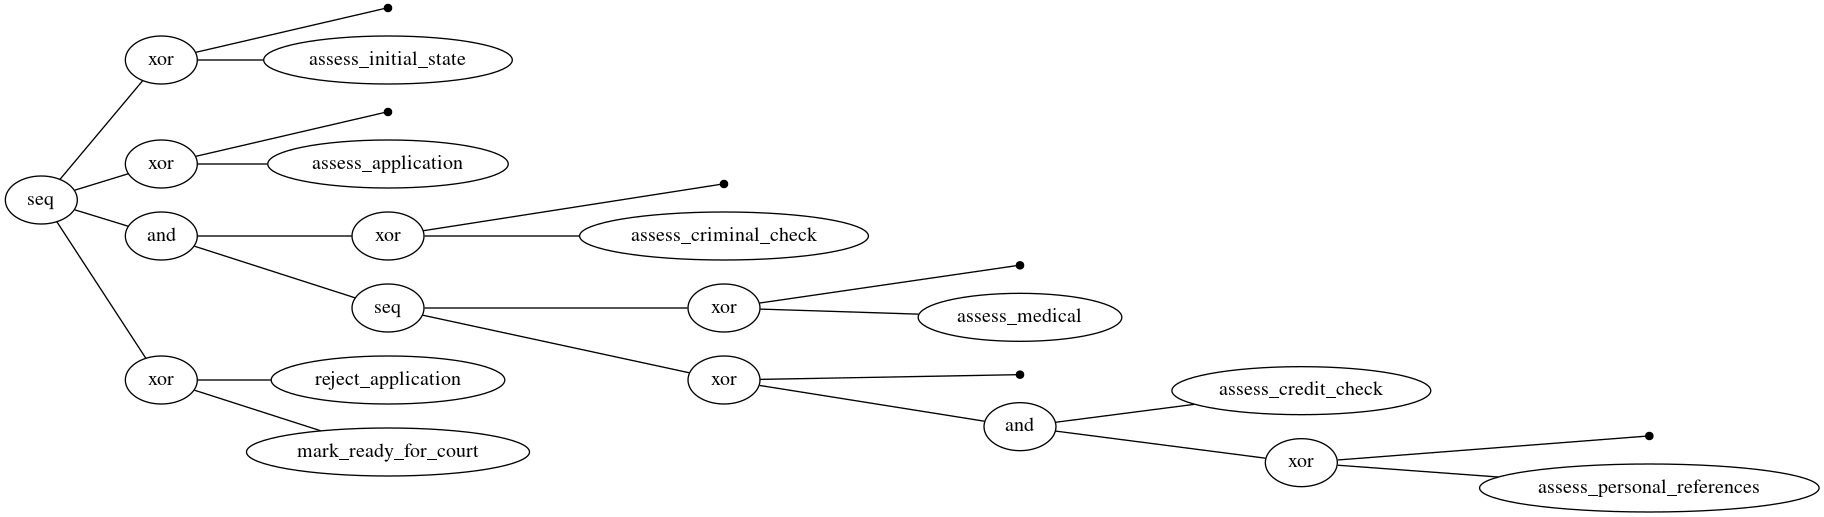

In [17]:
process_tree = pm4py.discover_process_tree_inductive(df)
print("Process tree")
pm4py.view_process_tree(process_tree)


Next, we draw a Directly-Follows Graph (DFG). DFG is not a process model. Rather it shows how one activity directly follows another in the log. It's useful if I want to focus on just that. For this agent, the inductively-discovered process was clear, so we are less interested in DFG. In messy logs, the DFG can tend to look like spaghetti. The DFG for this agent is spaghetti.

Here is how to read it.

Each box is an activity. The number in parentheses is a count of cases in which that activity occurred. Color is indicative of heat. Darker boxes represent more-frequent activities.

An arrow connects a pair of activities, showing that one activity directly follows another. The number on the arrow is the frequency, or number of times, that relationship is seen in the event log. Thick lines are more frequently-observed follows relationships.

Among the directly-follows relationsips we see are:
- assess_initial_state follows start of process (large circle at the far left). This is expected.
- assess_application follows start of process. This is somewhat less expected.
- assess_medical follows assess_application. This is expected.
- assess_criminal_check follows assess_medical. This is NOT expected.


DFG


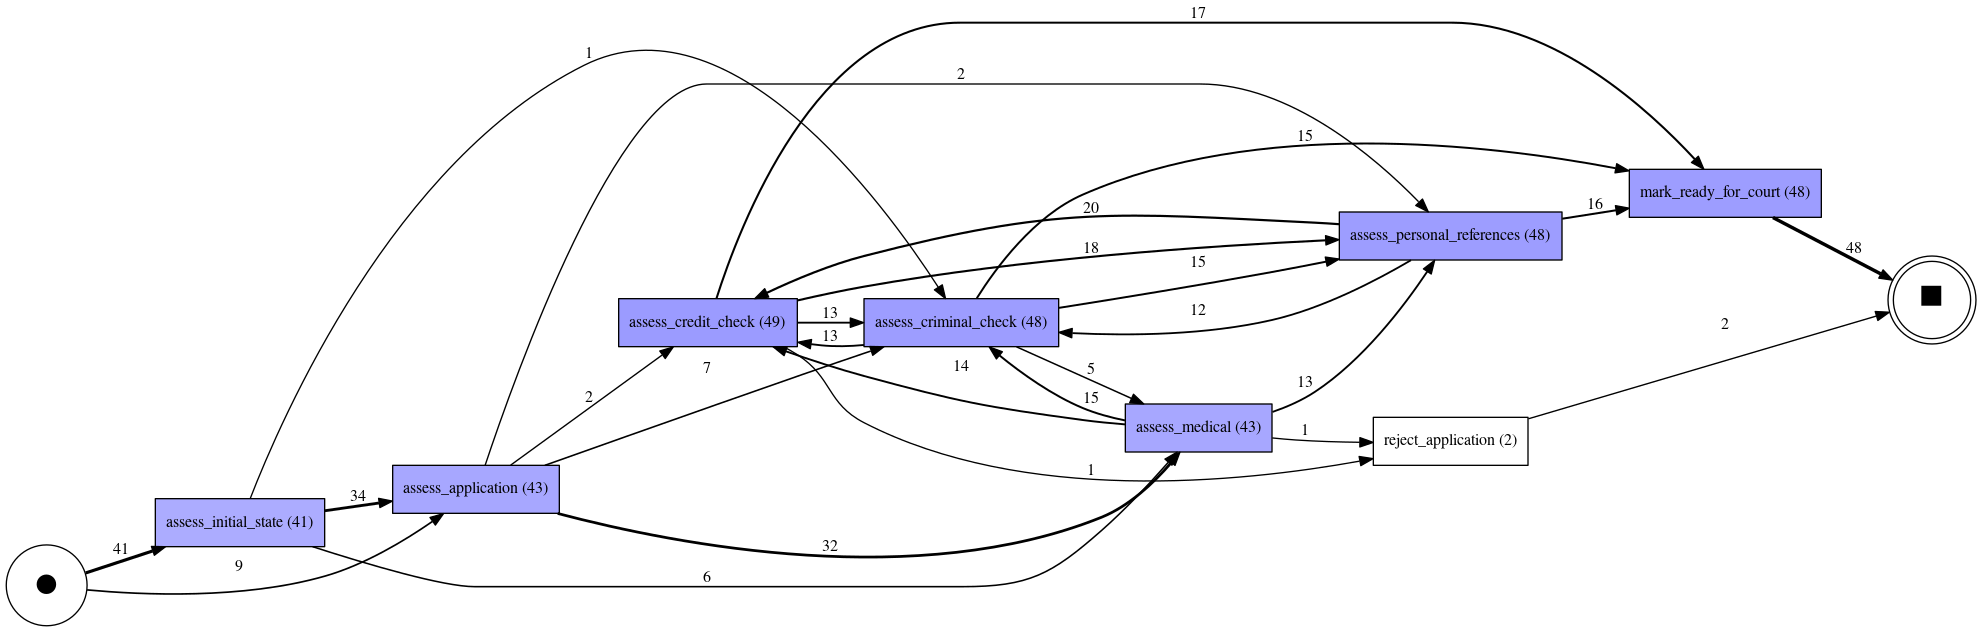

In [18]:
dfg, start_activities, end_activities = pm4py.discover_dfg(df)
print("DFG")
pm4py.view_dfg(dfg, start_activities, end_activities)


Next is a Heuristics Net. It is produced by the Heuristics Miner from above. It is like a cleaned-up DFG; it filters out noise and can detect concurrency. 

Here is what it shows for this agent:
- A Structured Lifecycle with Asynchronous Core: It maps an intake pipeline that always begins with assess_initial_state and ends at mark_ready_for_court (48 times) or a rare reject_application (2 times).
- An Interwoven Concurrent Block: The middle layer captures a parallel evaluation phase where assess_medical, assess_credit_check, and assess_personal_references execute concurrently.
- A Statistical Multi-Branch Join: It highlights that the agent must synchronize its independent threads, showing almost identical traffic frequencies funneling directly into the final court readiness milestone.

How do we see parallelism? The diagram proves parallelism through the mathematical symmetry of its traffic, showing that the concurrent assessment tasks split the workflow almost perfectly down the middle (14 vs 13) and then funnel into the final synchronization gate with nearly identical individual frequencies (16, 17, and 15). Because these paths remain open and separate rather than collapsing into a single sequential line or a circular feedback loop, the Heuristics Net visually confirms that these independent threads are executing simultaneously in production.

The diagram is easier to understand than the DFG and further highlights the unexpected ordering assess_medical and assess_criminal_check.


Heuristic net


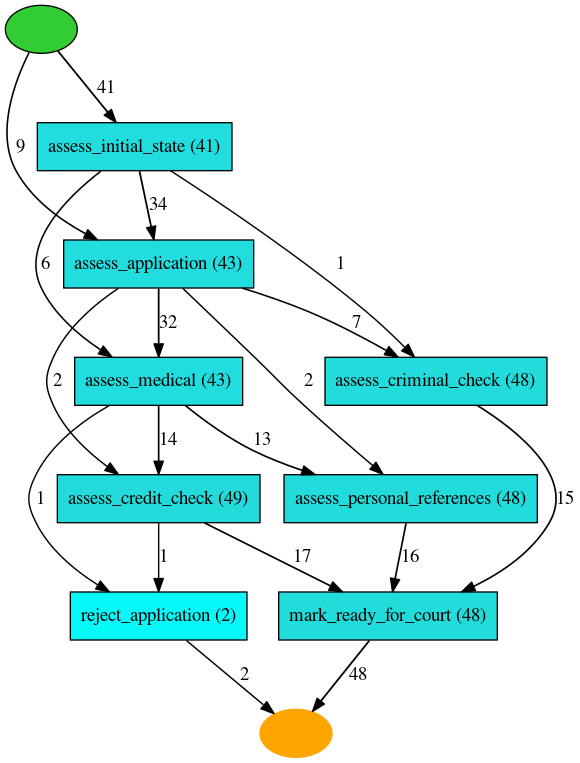

In [19]:
map=pm4py.discover_heuristics_net(df)
print("Heuristic net")
pm4py.view_heuristics_net(map)


Finally Footprints is a matrix of activities. It shows how each activity structurally related to each other activity.

Example: assess_application and mark_ready_for_court are not structurally related. The cell in the assess_application row and mark_ready_for_court column is #.

Example: assess_initial_state is directly followed by assess_application. The cell in the assess_initial_state row and assess_application column is >.

Example: assess_criminal_check and assess_credit_check occur in parallel. The cell in the assess_criminal_check row and assess_credit_check column is shown with parallel lines.

The matrix also shows unexpected *directly follows* relationships between assess_application and assess_credit_check, assess_criminal_check and assess_personal_references. Footprints does not indicate how frequent these are. The DFG and heuristic nets do indicate that. 

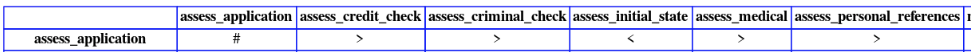


Footprints


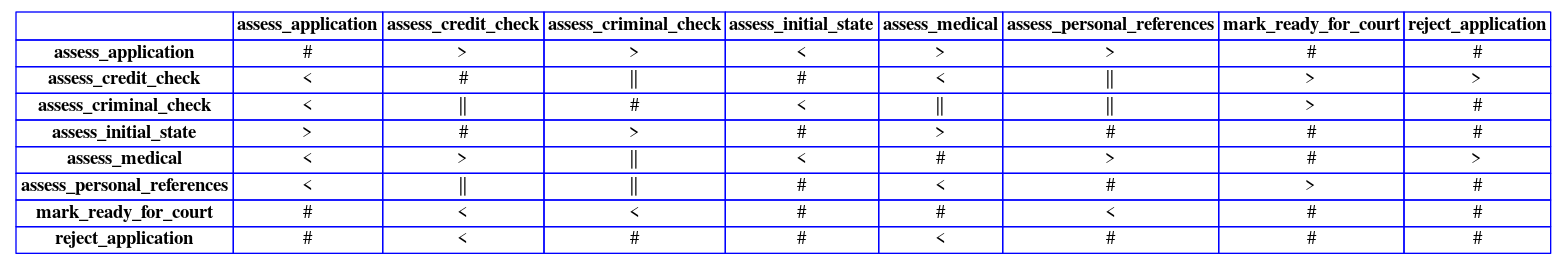

In [20]:
footprints = pm4py.discover_footprints(df)
print("Footprints")
pm4py.view_footprints(footprints)


We will run conformance later, but for now look at how bad the fitness is. 

In [49]:
pm4py.fitness_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm)


replaying log with TBR, completed traces ::   0%|          | 0/30 [00:00<?, ?it/s]

{'perc_fit_traces': 0.0,
 'average_trace_fitness': 0.38292929292929295,
 'log_fitness': 0.39029535864978904,
 'percentage_of_fitting_traces': 0.0}

Our BPMN model is event-driven and hard for the miner to make sense of. The message events in the model are not in the event log! The parallel nature in which updates can be made is not appararent. It's not a bad model, but let's give the miner a model that can be tied better to the event log. We could redraw the BPMN model in an editor, but let's sketch it out in the text language supported pm4py!

Generated Petri Net from Text String:


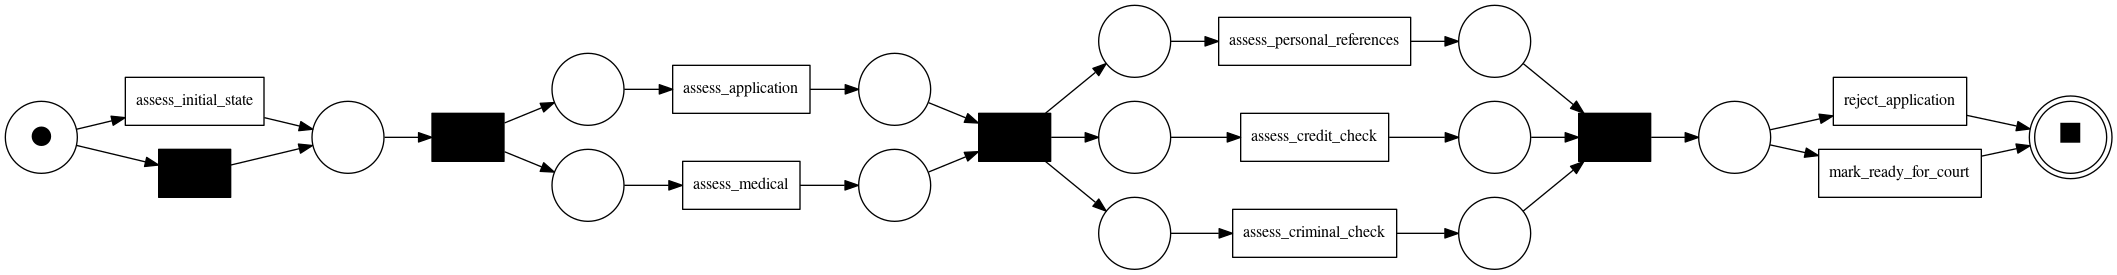

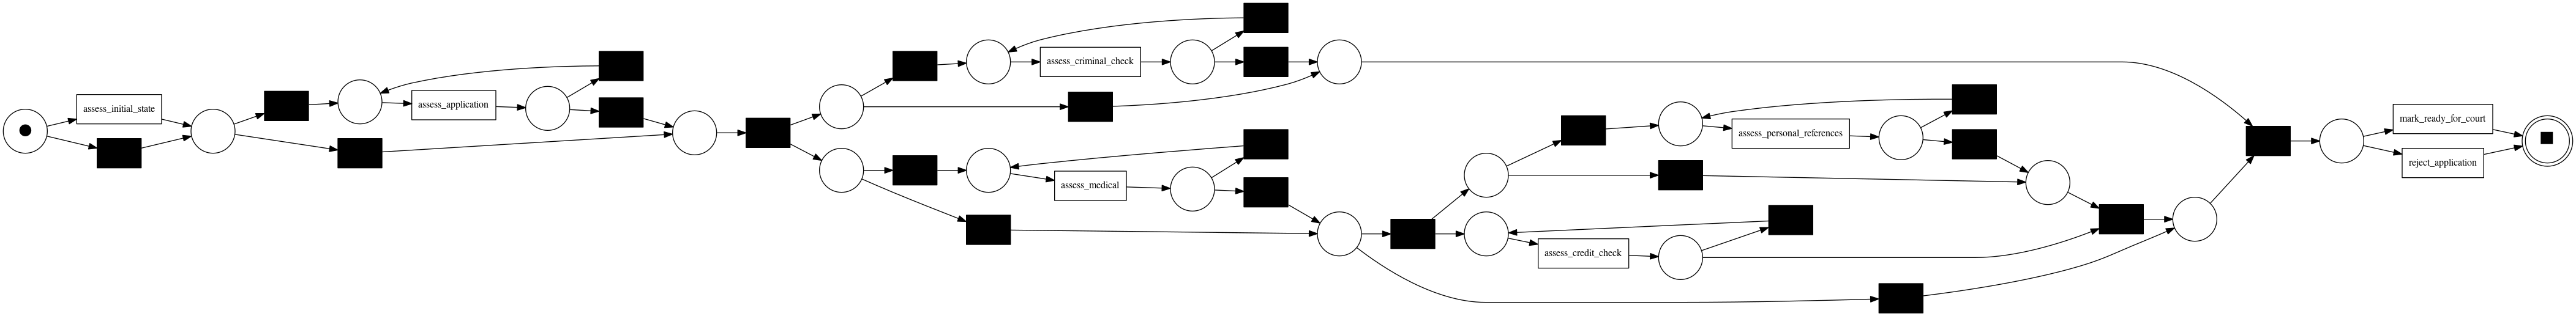

In [50]:
# 1. Optional Intake Gate
intake_phase = "X( 'assess_initial_state', tau )"

# 2. Required Application and Medical (Any order = Parallel '+')
app_completeness = "+( 'assess_application', 'assess_medical' )"

# 3. Required Background Screenings (Any order = Parallel '+')
screenings = "+( 'assess_criminal_check', 'assess_credit_check', 'assess_personal_references' )"

# 4. Final Outcomes (Exclusive Choice 'X')
outcome_phase = "X( 'mark_ready_for_court', 'reject_application' )"


# --- THE CORRECTED COMPILE ---
# We sequence the processing phases linearly: Intake -> Apps -> Screenings
core_processing = f"->( {intake_phase}, {app_completeness}, {screenings} )"

# Then we sequence the core processing highway straight into the outcome phase
final_narrative_string = f"->( {core_processing}, {outcome_phase} )"

intended_tree = pm4py.parse_process_tree(final_narrative_string)

# 3. Convert that Process Tree directly into a formal Petri Net
intended_pn_net, intended_pn_im, intended_pn_fm = pm4py.convert_to_petri_net(intended_tree)

# 4. View it immediately to confirm the structure layout is correct
print("Generated Petri Net from Text String:")
pm4py.view_petri_net(intended_pn_net, intended_pn_im, intended_pn_fm)

pm4py.view_petri_net(disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm)


## Conformance

Now we use pm4py conformance tools to assess how well the event log aligns with our intended model. We compare that to the discovered model.

We will use two ways to measure conformance:

- *Token-based replay*: An execution audit that replays the event log traces through the Petri net step-by-step. Petri Nets are all about passing tokens through the net! Token-based replay tracks compliance by counting "tokens" that are correctly consumed, missing (required but unavailable), or stranded (left over at execution end).
- *Alignment*: A cost-optimal synchronization method that maps the event log (Reality) directly against the model paths (Intent). It explicitly pairs actions into synchronous moves, moves on log (unintended agent drift), or moves on model (skipped architectural steps), revealing the exact point of divergence.

For each we measure fitness and precision. We do this for both the discovered model and the intended model.

- *Fitness* is the degree to which the event log traces can be successfully replayed by the model. High fitness means the architecture successfully accounts for all the tool paths and edge cases the agent actually executed in production.
- *Precision* is the degree to which the model restricts behavior not seen in the log. High precision means the architecture tightly constrains the agent, preventing it from wandering into unprescribed tool loops or "off-road" states that never occurred in reality.
We also visualize issues caught during conformance.

Here is what we expect to find:

- The discovered model will have 100 percent fitness because the Inductive Miner constructs the process tree specifically to explain and fit every case in the event log.
- The intended model will have high but not perfect fitness because, as we saw above, it does fit all variants. 
- The discovered model will have lower precision because, in order to guarantee absolute fitness and mathematical soundness, the inductive algorithm overgeneralizes, introducing allowable structural paths that were never actually visited by cases.
- The intended model is very precise because it is designed to strictly limit execution to a limited set of paths.

In [21]:
for s in [ 
    "\nintended fitness (token-based replay)", 
    pm4py.fitness_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered fitness (token-based replay)",
    pm4py.fitness_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    "\nintended precision (token-based replay)",
    pm4py.precision_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered precision (token-based replay)",
    pm4py.precision_token_based_replay(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]:
    print(s)

replaying log with TBR, completed traces ::   0%|          | 0/23 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/23 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/62 [00:00<?, ?it/s]

replaying log with TBR, completed traces ::   0%|          | 0/62 [00:00<?, ?it/s]


intended fitness (token-based replay)
{'perc_fit_traces': 60.0, 'average_trace_fitness': 0.9197417027417027, 'log_fitness': 0.9336108869488666, 'percentage_of_fitting_traces': 60.0}

discovered fitness (token-based replay)
{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}

intended precision (token-based replay)
0.8166351606805293

discovered precision (token-based replay)
0.44834307992202727


Next, let's gather diagnostics for the token-based replay to see why the intended model's fitness was less than 100 percent.

In [22]:
tbr_results = pm4py.conformance_diagnostics_token_based_replay(df, intended_pn_net,intended_pn_im,intended_pn_fm)
pmagent_util.dump_conformance_diagnostics(df, tbr_results, "token")

replaying log with TBR, completed traces ::   0%|          | 0/23 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (TOKEN METHOD) ===
Found 14 distinct non-compliance patterns:

⚠️  Pattern Detected: 2 occurrences
   Impacted Case IDs: [0c3adef5-5fe2-43aa-989d-4e09b235578f, f7a403f0-fa25-4870-86f9-90397aef03d5]
   Discovered Variant: assess_initial_state->assess_application->assess_criminal_check->assess_credit_check->assess_personal_references->mark_ready_for_court
   Compliance Issue: The agent broke sequence rules. It attempted to execute 
                     'assess_credit_check', 'assess_criminal_check', 'assess_personal_references' before prerequisite phase gates opened/closed.
   Replay Metrics:     Missing Tokens: 3 | Stranded Tokens: 2

--------------------------------------------------------------------------------

⚠️  Pattern Detected: 1 occurrences
   Impacted Case IDs: [1e8fb94e-adc0-4bab-88c7-3adf312a78d8]
   Discovered Variant: assess_initial_state->assess_criminal_check->assess_medical->assess_personal_references->assess_credit_check->mark_ready

**Let's summarize the issues**:

**1. The Core Phase-Gate Collapse (15 Cases)**
By far the most severe and frequent issue, this problem impacts 15 cases across 10 different variants.

The Symptom: The agent is attempting to fire background verification tools (assess_credit_check, assess_criminal_check, and assess_personal_references) out of order, forcing PM4Py to register 3 missing tokens and 2 stranded tokens per run.

The Root Cause: The intended model treats assess_medical or assess_application as strict, upstream prerequisite phase-gates that must open and close before background screening can start. Instead of waiting, the agent is jumping straight from initial ingestion into background evaluations. The downstream tokens are getting stranded because the required synchronization state machine was never properly initialized.

**2. The Premature Ingestion Skip (4 Cases)**

The Symptom: The replay engine registers exactly 1 missing token and 1 stranded token.

The Root Cause: In these variants, the agent successfully executes assess_initial_state and assess_application, but then fires assess_criminal_check before hitting the required assess_medical node. By swapping the order or trying to handle the criminal check prematurely, the agent breaks the rigid block sequence required by your intended pipeline layout.

**3. Orphaned Initialization / Mid-Pipeline Exit (2 Cases)**

The Symptom: The agent completely skips the mandatory initialization block (assess_initial_state) and starts the entire case directly at assess_application. When the agent decides to trigger a reject_application, the engine drops 1 missing token and strands 2 to 3 tokens.

The Root Cause: Because the case never officially initialized through the correct state, the tokens required to process a clean, compliant shutdown do not exist. The agent is effectively terminating a phantom thread, leaving orphaned state memory (the stranded tokens) floating in your runtime pipeline.

We do similar checks on fitness and precision using alignments. The numbers are similar to token-based because both methods are evaluating the exact same underlying reality—the interplay between the log's traces and the model's paths—just using different mathematical lenses.

When the event log is clean, as for this agent, the metrics will naturally converge on nearly identical scores.

In [24]:
for s in [ 
    "\nintended fitness (alignments)", 
    pm4py.fitness_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered fitness (alignments)",
    pm4py.fitness_alignments(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm ),
    "\nintended precision (alignments)",
    pm4py.precision_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm),
    "\ndiscovered precision (alignments)",
    pm4py.precision_alignments(df, disc_pn_ind_net, disc_pn_ind_im, disc_pn_ind_fm )
]:
    print(s)

aligning log, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/62 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/62 [00:00<?, ?it/s]


intended fitness (alignments)
{'percFitTraces': 60.0, 'averageFitness': 0.9503589743589741, 'percentage_of_fitting_traces': 60.0, 'average_trace_fitness': 0.9503589743589741, 'log_fitness': 0.9533521430179094}

discovered fitness (alignments)
{'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9999395218191837}

intended precision (alignments)
0.8166351606805293

discovered precision (alignments)
0.44834307992202727


Run diagnostics on the fitness of the intended model. You will need a wide screen.

In [25]:
aln_results = pm4py.conformance_diagnostics_alignments(df, intended_pn_net,intended_pn_im,intended_pn_fm)
pmagent_util.dump_conformance_diagnostics(df, aln_results, "alignment")

aligning log, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

=== NON-COMPLIANT AGENT TRACE AUDIT (ALIGNMENT METHOD) ===
Found 14 distinct non-compliance patterns:

⚠️  Pattern Detected: 2 occurrences
   Impacted Case IDs: [0c3adef5-5fe2-43aa-989d-4e09b235578f, f7a403f0-fa25-4870-86f9-90397aef03d5]
   [ VISUAL ALIGNMENT LADDER ]
       Log (Reality):   [ assess_initial_state | >>   | >>             | assess_application | >>   | assess_criminal_check | assess_credit_check | assess_personal_references | >>   | mark_ready_for_court ]
                            |                     ▼ SKIP   ▼ SKIP            |                   ▼ SKIP    |                       |                     |                           ▼ SKIP    |                  
       Model (Intent):  [ assess_initial_state | None | assess_medical | assess_application | None | assess_criminal_check | assess_credit_check | assess_personal_references | None | mark_ready_for_court ]

   Alignment Metrics:  Fitness Score: 0.92 | Total Alignment Cost: 10003

---------------------------------

Finally, we can visualize at the intended model (as Petri Net) with alignment issues indicated.

In each box are two numbers. The first is the number of deviations. The second is the total number of occurrences. Box color represents deviation "heat".

aligning log, completed variants ::   0%|          | 0/23 [00:00<?, ?it/s]

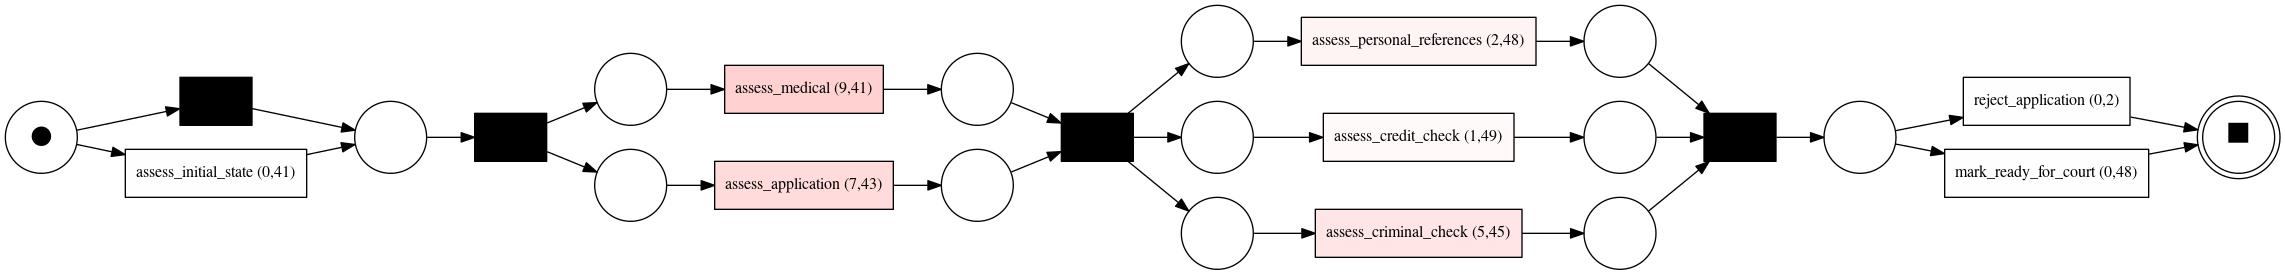

In [26]:
from pm4py.visualization.petri_net import visualizer as pn_visualizer
gviz = pn_visualizer.apply(intended_pn_net,intended_pn_im,intended_pn_fm,
                           log=df, variant=pn_visualizer.Variants.ALIGNMENTS)
pn_visualizer.view(gviz)

## Findings and Recommendations

We invested effort to draw an BPMN model that captured the event-driven character of the agentic flow, but then saw how deeply different it was from the miner-disccovered model. We decided to redraw our process flow as activity-based: still agreeing with the agent's design, but more comparable to the discovered model. 

Our intended model fit about 60 percent of the cases in the event log. The malfit cases of concern were those in which criminal checking was done too early. Our agent uses a ReAct pattern. so the recommendation is to look at whether the LLM is right to allow this. 